# PostgreSQL vs Neo4j — Benchmark Analysis

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
PG_COLOR  = '#4C72B0'
NEO_COLOR = '#DD8452'

timing = pd.read_csv('benchmark/results/timing.csv')
plans  = pd.read_csv('benchmark/results/plans.csv')

# Drop warmup run (run == 0)
timing = timing[timing['run'] > 0].copy()

# Convert to milliseconds for readability
timing['pg_time_ms']  = timing['pg_time_s']  * 1000
timing['neo_time_ms'] = timing['neo_time_s'] * 1000

print('Scales:',  sorted(timing['scale'].unique()))
print('Queries:', timing['query_id'].unique())
print('Runs per query/scale:', timing.groupby(['query_id','scale']).size().unique())

Scales: [np.int64(25), np.int64(50), np.int64(75), np.int64(100)]
Queries: <ArrowStringArray>
[      'multihop_nutrients_for_recipe', 'multihop_recipes_sharing_ingredient',
       'multihop_filter_mid_traversal',        'agg_total_nutrient_in_recipe',
         'agg_avg_nutrient_per_recipe',            'agg_recipes_by_prep_time',
         'mixed_most_used_ingredients',       'mixed_ingredient_cooccurrence',
    'mixed_recipes_above_avg_nutrient',            'varlen_reachable_recipes']
Length: 10, dtype: str
Runs per query/scale: [9]


In [33]:
import pandas as pd
from IPython.display import display, HTML

SCALES = [25, 50, 75, 100]
DATA_DIR = 'data/scales'

# ── Load parquet stats ───────────────────────────────────────────────────────
rows = []
for s in SCALES:
    recipes     = pd.read_parquet(f'{DATA_DIR}/recipes_{s}.parquet')
    ingredients = pd.read_parquet(f'{DATA_DIR}/ingredients_{s}.parquet')
    has_ing     = pd.read_parquet(f'{DATA_DIR}/has_ingredient_{s}.parquet')
    has_nut     = pd.read_parquet(f'{DATA_DIR}/has_nutrient_{s}.parquet')

    rows.append({
        'scale':          f'{s}%',
        # nodes
        'recipes':        len(recipes),
        'ingredients':    len(ingredients),
        'nutrients':      has_nut['nutrient_id'].nunique(),
        # edges
        'has_ingredient': len(has_ing),
        'has_nutrient':   len(has_nut),
        # totals
        'total_nodes':    len(recipes) + len(ingredients) + has_nut['nutrient_id'].nunique(),
        'total_edges':    len(has_ing) + len(has_nut),
        # density
        'ing/recipe':     round(len(has_ing) / len(recipes), 2),
        'nut/ingredient': round(len(has_nut) / len(ingredients), 2),
    })

df = pd.DataFrame(rows).set_index('scale')

# ── Split into logical groups for display ────────────────────────────────────
node_cols    = ['recipes', 'ingredients', 'nutrients', 'total_nodes']
edge_cols    = ['has_ingredient', 'has_nutrient', 'total_edges']
density_cols = ['ing/recipe', 'nut/ingredient']

def show(title, sub_df, fmt='{:,.0f}'):
    display(HTML(f'<h3 style="margin-top:1.5em;font-family:sans-serif">{title}</h3>'))
    display(
        sub_df.style
              .format(fmt)
              .set_table_styles([{'selector': 'th', 'props': [('background','#2a2a2a'),('padding','6px 14px')]}])
              .bar(color="#737c85")
    )

show('Nodes per scale',          df[node_cols])
show('Edges per scale',          df[edge_cols])
show('Density (avg edges/node)', df[density_cols], fmt='{:.2f}')


,recipes,ingredients,nutrients,total_nodes
scale,,,,
25%,"42,449","4,805",142,"47,396"
50%,"84,898","4,869",142,"89,909"
75%,"127,347","4,870",142,"132,359"
100%,"169,796","4,870",142,"174,808"


,has_ingredient,has_nutrient,total_edges
scale,,,
25%,"373,809","303,718","677,527"
50%,"746,688","308,044","1,054,732"
75%,"1,120,411","308,106","1,428,517"
100%,"1,495,774","308,106","1,803,880"


,ing/recipe,nut/ingredient
scale,,
25%,8.81,63.21
50%,8.80,63.27
75%,8.80,63.27
100%,8.81,63.27


## 1. Summary Statistics

In [34]:
summary = (
    timing
    .groupby(['query_id', 'category', 'scale'])
    .agg(
        pg_median  = ('pg_time_ms',  'median'),
        pg_p75     = ('pg_time_ms',  lambda x: x.quantile(0.75)),
        neo_median = ('neo_time_ms', 'median'),
        neo_p75    = ('neo_time_ms', lambda x: x.quantile(0.75)),
    )
    .reset_index()
)

summary['faster'] = np.where(summary['pg_median'] < summary['neo_median'], 'PostgreSQL', 'Neo4j')
summary['speedup'] = (summary[['pg_median','neo_median']].max(axis=1) /
                      summary[['pg_median','neo_median']].min(axis=1)).round(2)

pd.set_option('display.float_format', '{:.3f}'.format)
summary

,query_id,category,scale,pg_median,pg_p75,neo_median,neo_p75,faster,speedup
0,agg_avg_nutrient_per_recipe,aggregation,25,2224.853,2234.793,4044.920,4092.367,PostgreSQL,1.820
1,agg_avg_nutrient_per_recipe,aggregation,50,4452.115,4472.165,7850.711,8019.460,PostgreSQL,1.760
2,agg_avg_nutrient_per_recipe,aggregation,75,6586.399,6603.581,11430.570,11484.424,PostgreSQL,1.740
3,agg_avg_nutrient_per_recipe,aggregation,100,9055.749,9072.408,15302.952,15319.450,PostgreSQL,1.690
4,agg_recipes_by_prep_time,aggregation,25,76.261,79.499,164.965,167.712,PostgreSQL,2.160
5,agg_recipes_by_prep_time,aggregation,50,182.170,183.798,258.558,265.445,PostgreSQL,1.420
6,agg_recipes_by_prep_time,aggregation,75,197.381,200.086,336.273,356.634,PostgreSQL,1.700
7,agg_recipes_by_prep_time,aggregation,100,264.892,271.666,431.864,434.335,PostgreSQL,1.630
8,agg_total_nutrient_in_recipe,aggregation,25,0.512,0.600,1.362,1.521,PostgreSQL,2.660
9,agg_total_nutrient_in_recipe,aggregation,50,0.516,0.577,1.150,1.299,PostgreSQL,2.230


## 2. Per-Query Timing: PostgreSQL vs Neo4j (all scales)

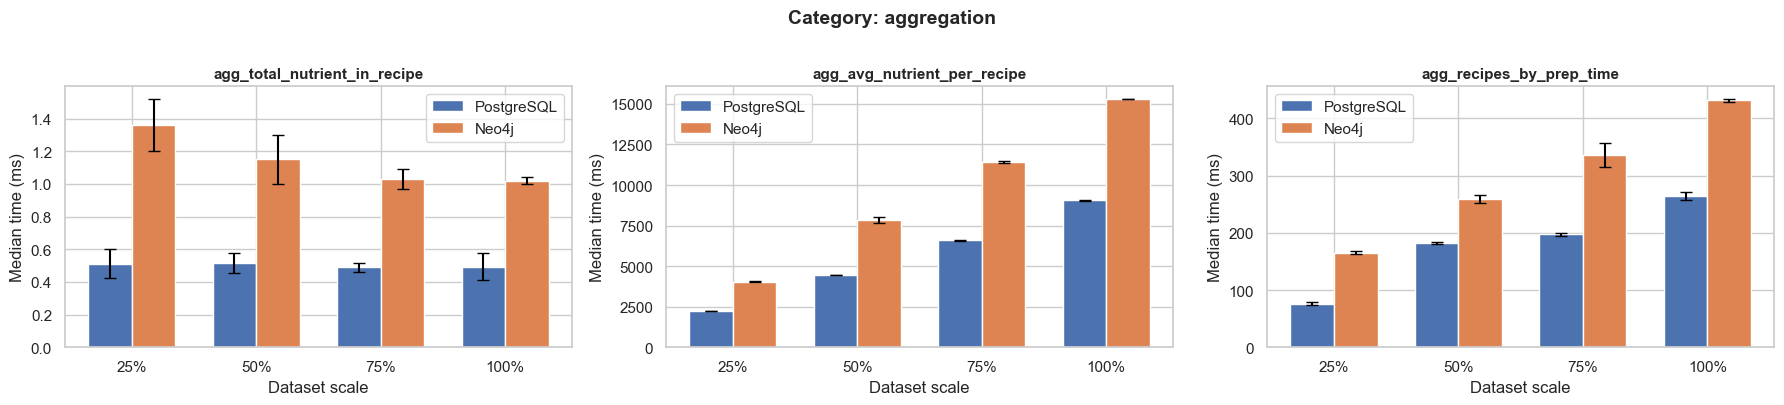

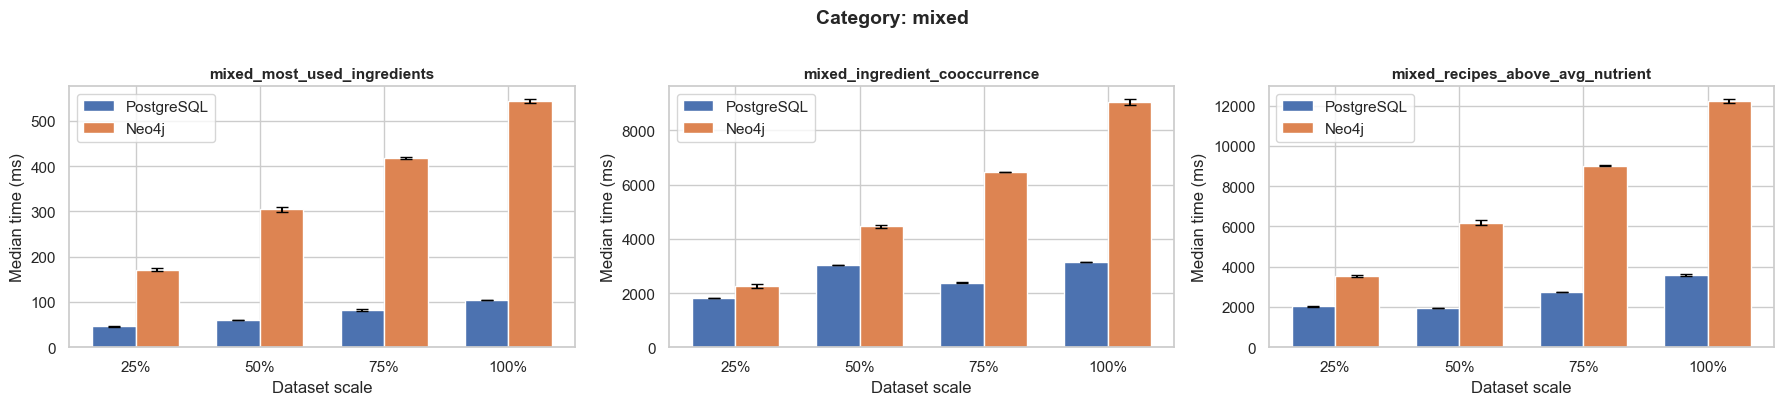

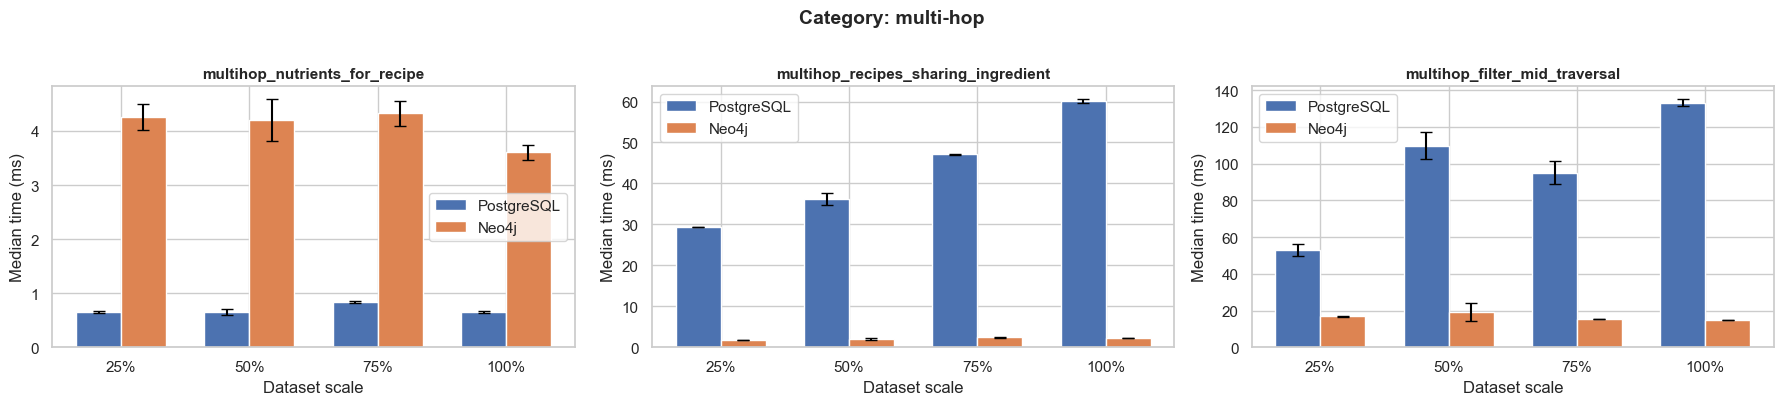

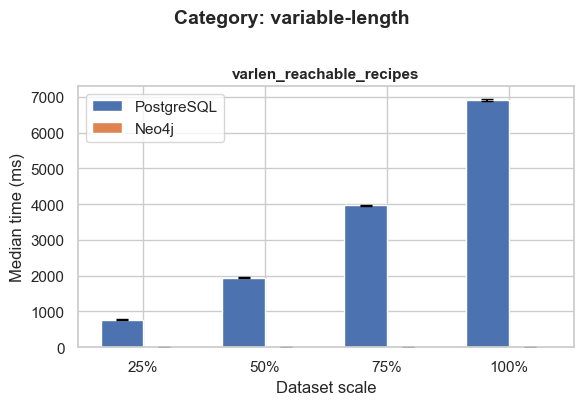

In [35]:
import math

query_ids  = timing['query_id'].unique()
categories = timing.set_index('query_id')['category'].to_dict()
scales     = sorted(timing['scale'].unique())

# Group query_ids by category
from collections import defaultdict
category_queries = defaultdict(list)
for qid in query_ids:
    category_queries[categories[qid]].append(qid)

for cat, qids in sorted(category_queries.items()):
    n_cols = len(qids)
    n_rows = math.ceil(len(qids) / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
    
    if n_rows == 1 and n_cols == 1:
        axes_flat = [axes]
    elif n_rows == 1 or n_cols == 1:
        axes_flat = axes.flatten()
    else:
        axes_flat = axes.flatten()

    fig.suptitle(f"Category: {cat}", fontsize=14, fontweight='bold', y=1.01)

    for ax, qid in zip(axes_flat, qids):
        x  = np.arange(len(scales))
        w  = 0.35
        df = summary[summary['query_id'] == qid].sort_values('scale')
        yerr_pg  = (df['pg_p75'].values  - df['pg_median'].values).clip(min=0)
        yerr_neo = (df['neo_p75'].values - df['neo_median'].values).clip(min=0)
        ax.bar(x - w/2, df['pg_median'].values,  w, label='PostgreSQL', color=PG_COLOR)
        ax.bar(x + w/2, df['neo_median'].values, w, label='Neo4j',      color=NEO_COLOR)
        ax.errorbar(x - w/2, df['pg_median'].values,  yerr=yerr_pg,  fmt='none', color='black', capsize=4)
        ax.errorbar(x + w/2, df['neo_median'].values, yerr=yerr_neo, fmt='none', color='black', capsize=4)

        ax.set_title(f"{qid}", fontsize=11, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels([f'{s}%' for s in scales])
        ax.set_xlabel('Dataset scale')
        ax.set_ylabel('Median time (ms)')
        ax.legend()

    for ax in axes_flat[len(qids):]:
        ax.set_visible(False)

    plt.tight_layout()
    safe_cat = cat.replace(' ', '_').replace('/', '_')
    plt.savefig(f'benchmark/results/per_query_bars_{safe_cat}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 3. Scaling Behaviour — Execution Time vs Dataset Size

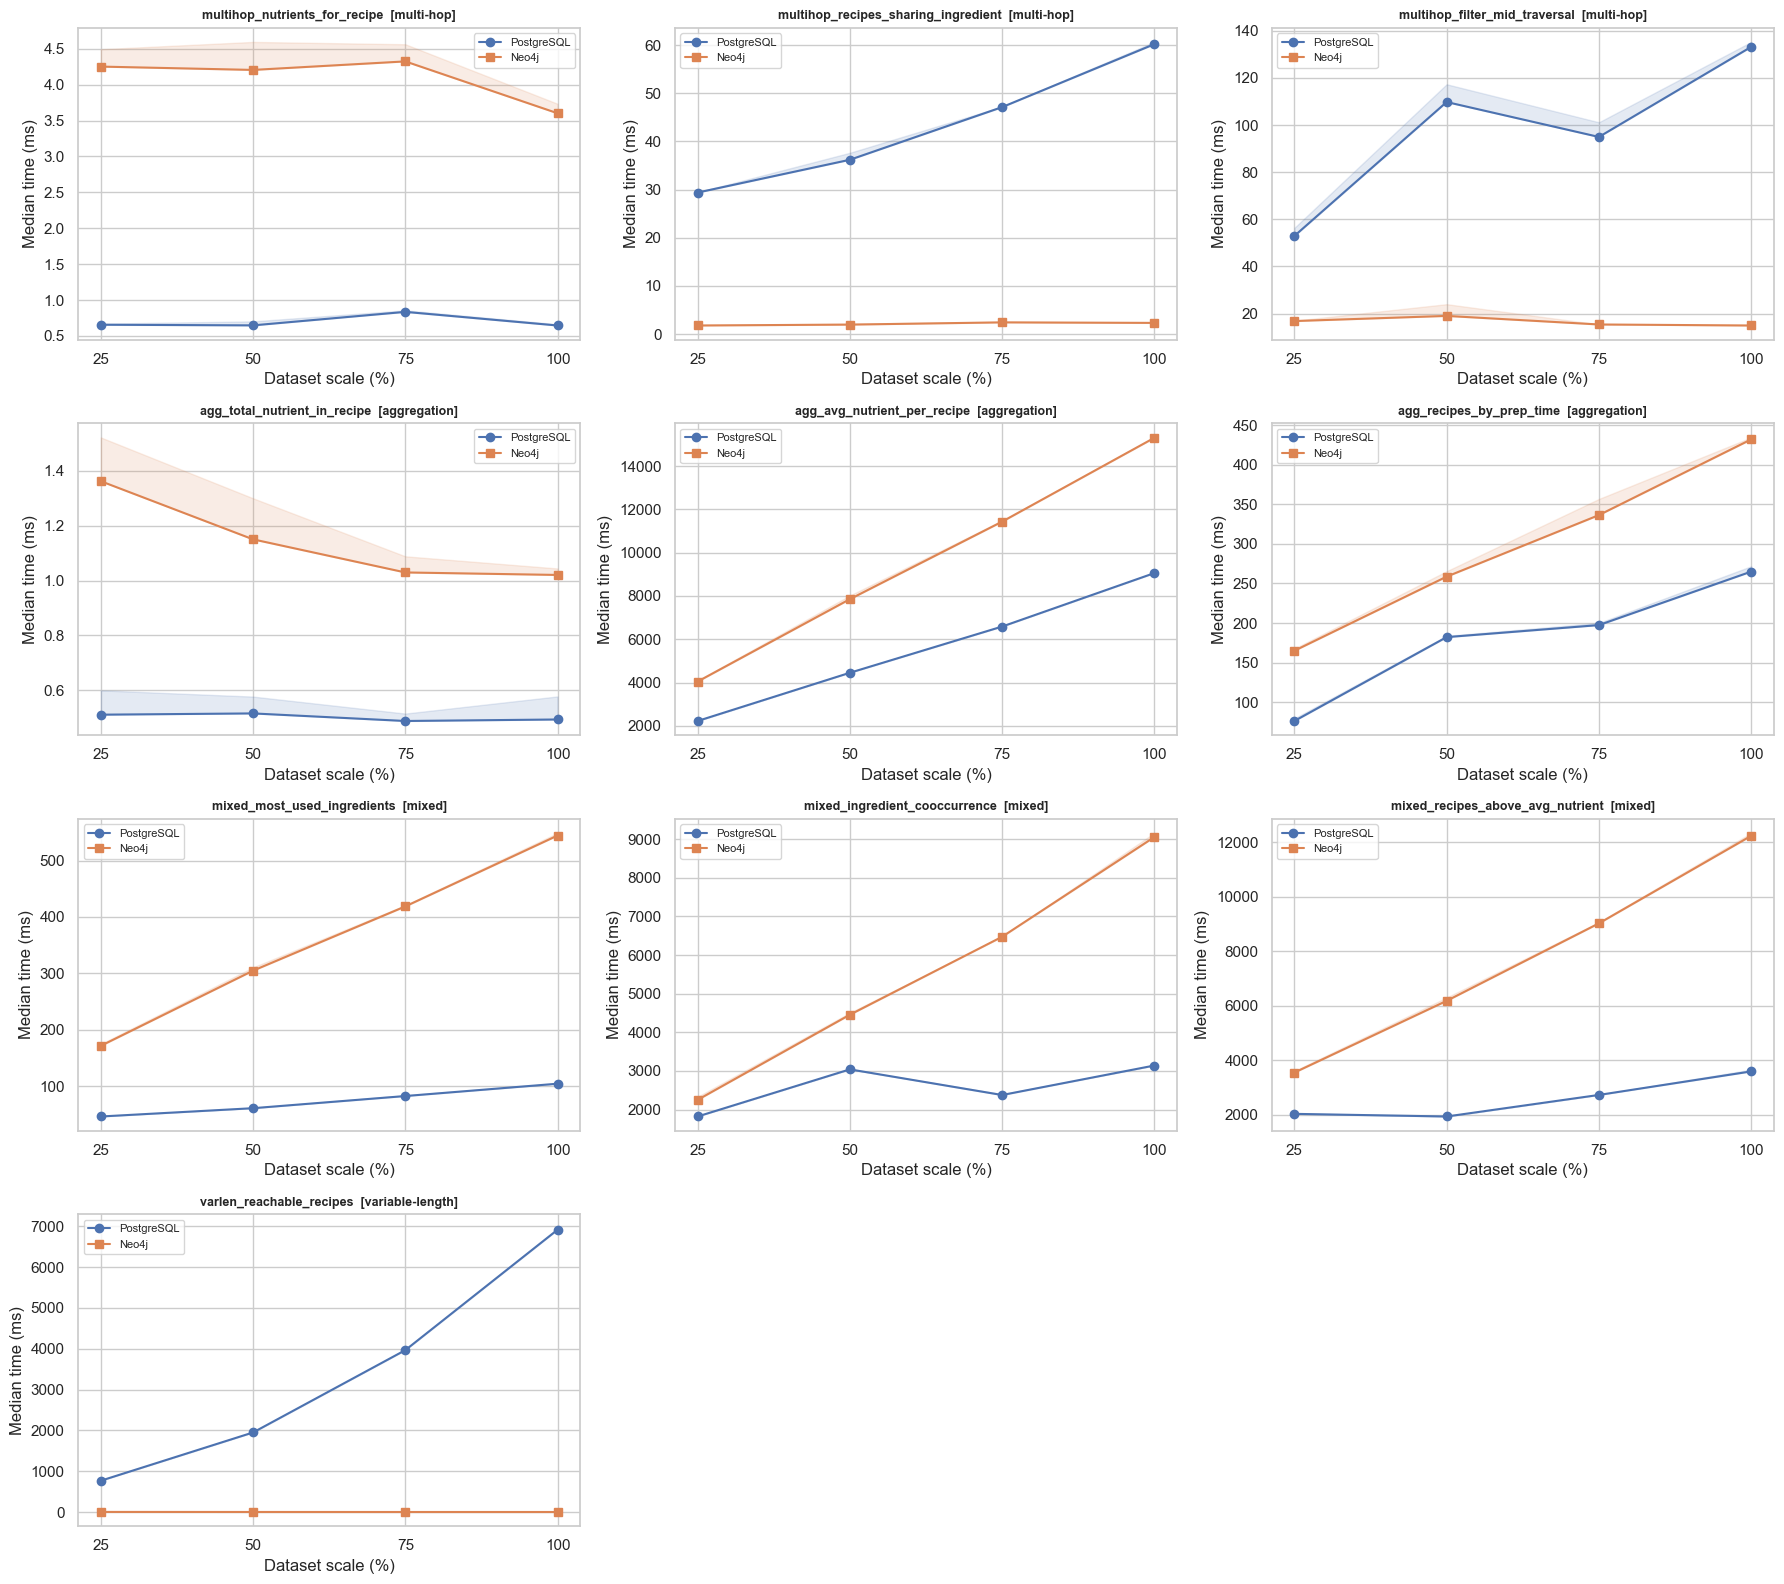

In [36]:
n_cols = 3
n_rows = math.ceil(len(query_ids) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 4 * n_rows))
axes = axes.flatten()

for ax, qid in zip(axes, query_ids):
    df = summary[summary['query_id'] == qid]
    ax.plot(df['scale'], df['pg_median'],  marker='o', label='PostgreSQL', color=PG_COLOR)
    ax.plot(df['scale'], df['neo_median'], marker='s', label='Neo4j',      color=NEO_COLOR)
    ax.fill_between(df['scale'], df['pg_median'],  df['pg_p75'],  alpha=0.15, color=PG_COLOR)
    ax.fill_between(df['scale'], df['neo_median'], df['neo_p75'], alpha=0.15, color=NEO_COLOR)
    ax.set_title(f"{qid}  [{categories[qid]}]", fontsize=9, fontweight='bold')
    ax.set_xlabel('Dataset scale (%)')
    ax.set_ylabel('Median time (ms)')
    ax.set_xticks(scales)
    ax.legend(fontsize=8)

for ax in axes[len(query_ids):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('benchmark/results/scaling_lines.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Category-Level Summary

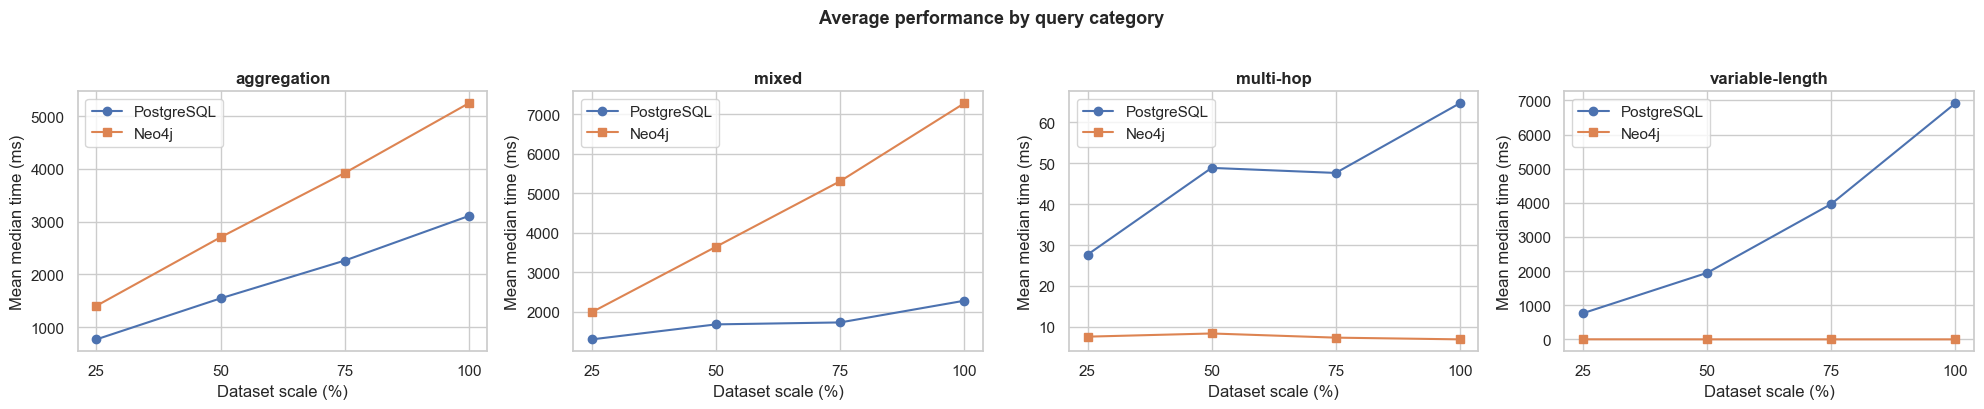

In [37]:
cat_summary = (
    summary
    .groupby(['category', 'scale'])
    .agg(pg_median=('pg_median','mean'), neo_median=('neo_median','mean'))
    .reset_index()
)

categories_list = cat_summary['category'].unique()
fig, axes = plt.subplots(1, len(categories_list), figsize=(5 * len(categories_list), 4), sharey=False)

for ax, cat in zip(axes, categories_list):
    df = cat_summary[cat_summary['category'] == cat]
    ax.plot(df['scale'], df['pg_median'],  marker='o', label='PostgreSQL', color=PG_COLOR)
    ax.plot(df['scale'], df['neo_median'], marker='s', label='Neo4j',      color=NEO_COLOR)
    ax.set_title(cat, fontweight='bold')
    ax.set_xlabel('Dataset scale (%)')
    ax.set_ylabel('Mean median time (ms)')
    ax.set_xticks(scales)
    ax.legend()

plt.suptitle('Average performance by query category', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('benchmark/results/category_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Query Plan Analysis

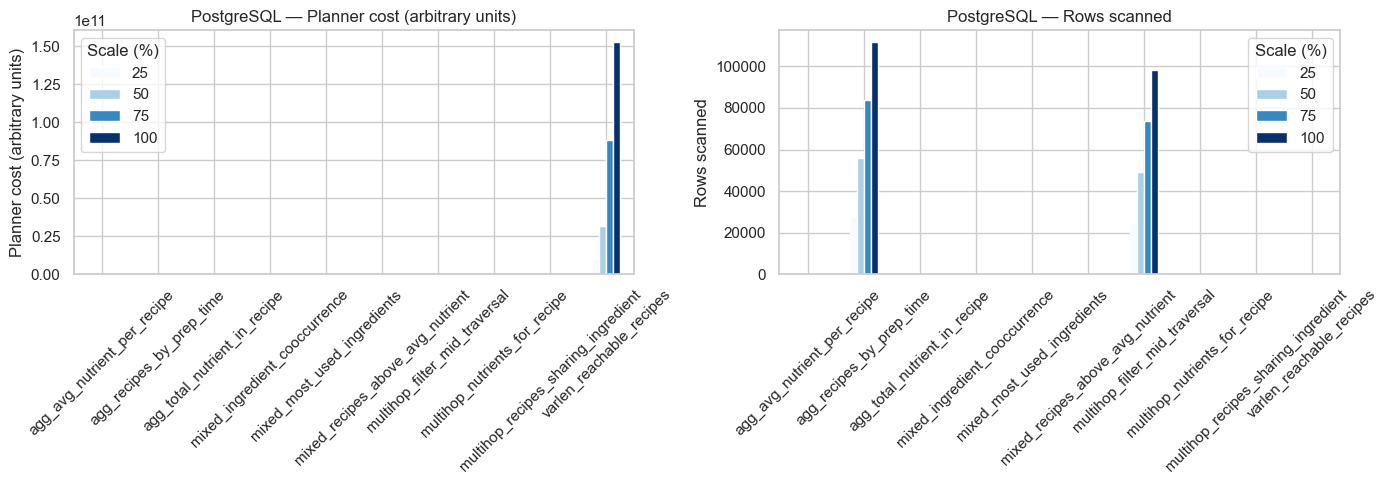

In [38]:
# PostgreSQL: cost and rows scanned
pg_plan_cols = ['query_id', 'category', 'scale', 'pg_total_cost', 'pg_rows', 'pg_actual_total_time']
pg_plans = plans[[c for c in pg_plan_cols if c in plans.columns]].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, label in zip(
    axes,
    ['pg_total_cost', 'pg_rows'],
    ['Planner cost (arbitrary units)', 'Rows scanned']
):
    if metric not in pg_plans.columns:
        ax.set_visible(False)
        continue
    pivot = pg_plans.pivot_table(index='query_id', columns='scale', values=metric)
    pivot.plot(kind='bar', ax=ax, colormap='Blues')
    ax.set_title(f'PostgreSQL — {label}')
    ax.set_xlabel('')
    ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Scale (%)')

plt.tight_layout()
plt.savefig('benchmark/results/pg_plans.png', dpi=150, bbox_inches='tight')
plt.show()

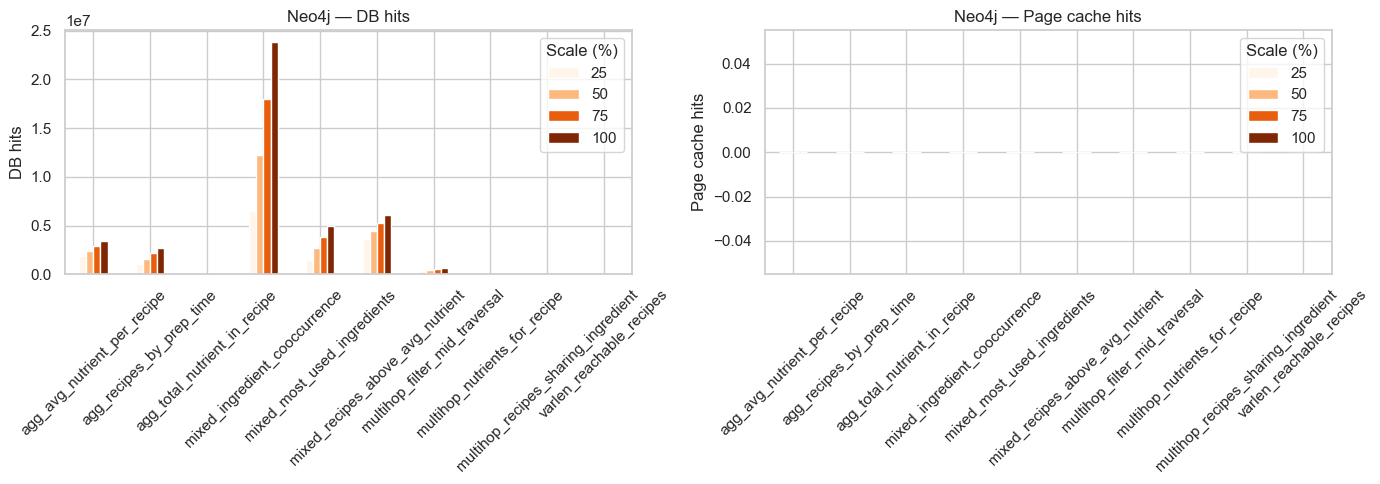

In [39]:
# Neo4j: db hits and page cache
neo_plan_cols = ['query_id', 'category', 'scale', 'neo_db_hits', 'neo_page_cache_hits', 'neo_page_cache_misses']
neo_plans = plans[[c for c in neo_plan_cols if c in plans.columns]].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, label in zip(
    axes,
    ['neo_db_hits', 'neo_page_cache_hits'],
    ['DB hits', 'Page cache hits']
):
    if metric not in neo_plans.columns:
        ax.set_visible(False)
        continue
    pivot = neo_plans.pivot_table(index='query_id', columns='scale', values=metric)
    pivot.plot(kind='bar', ax=ax, colormap='Oranges')
    ax.set_title(f'Neo4j — {label}')
    ax.set_xlabel('')
    ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(title='Scale (%)')

plt.tight_layout()
plt.savefig('benchmark/results/neo4j_plans.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. DB Hits vs Rows Scanned — Side by Side

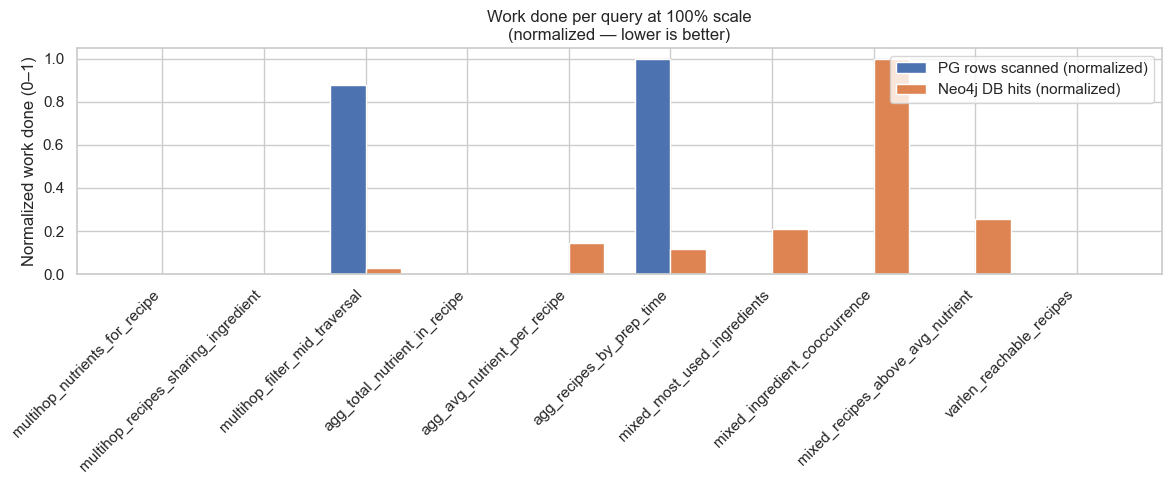

In [40]:
# Compare the 'work done' by each DB per query at full scale
full_scale = plans[plans['scale'] == 100].copy()

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(full_scale['query_id']))
w = 0.35

if 'pg_rows' in full_scale.columns and 'neo_db_hits' in full_scale.columns:
    # Normalize both to 0-1 for fair visual comparison
    pg_norm  = full_scale['pg_rows']    / full_scale['pg_rows'].max()
    neo_norm = full_scale['neo_db_hits']/ full_scale['neo_db_hits'].max()

    ax.bar(x - w/2, pg_norm,  w, label='PG rows scanned (normalized)',  color=PG_COLOR)
    ax.bar(x + w/2, neo_norm, w, label='Neo4j DB hits (normalized)',     color=NEO_COLOR)
    ax.set_xticks(x)
    ax.set_xticklabels(full_scale['query_id'], rotation=45, ha='right')
    ax.set_ylabel('Normalized work done (0–1)')
    ax.set_title('Work done per query at 100% scale\n(normalized — lower is better)')
    ax.legend()
    plt.tight_layout()
    plt.savefig('benchmark/results/work_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('pg_rows or neo_db_hits columns not found in plans.csv — check runner output')

## 7. Query verbosity/complexity comparison

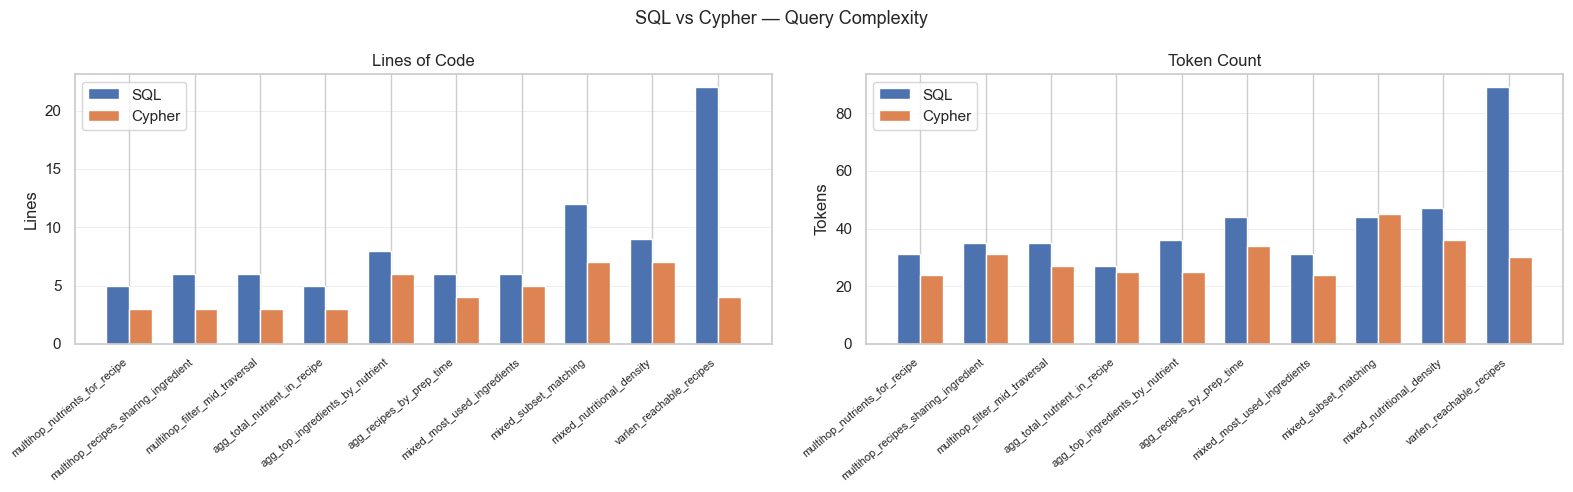

In [41]:
import re
import numpy as np
import matplotlib.pyplot as plt
from benchmark.queries import QUERIES

# ── Metrics ───────────────────────────────────────────────────────────────────

def count_lines(q):
    return len([l for l in q.strip().splitlines() if l.strip()])

def count_tokens(q):
    return len(re.findall(r'\w+', q))

ids           = [q["id"]           for q in QUERIES]
sql_lines     = [count_lines(q["sql"])     for q in QUERIES]
cypher_lines  = [count_lines(q["cypher"])  for q in QUERIES]
sql_tokens    = [count_tokens(q["sql"])    for q in QUERIES]
cypher_tokens = [count_tokens(q["cypher"]) for q in QUERIES]

x = np.arange(len(ids))
W = 0.35

# ── Plot ──────────────────────────────────────────────────────────────────────

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("SQL vs Cypher — Query Complexity", fontsize=13)

for ax, sql_vals, cypher_vals, ylabel, title in [
    (ax1, sql_lines,  cypher_lines,  "Lines",  "Lines of Code"),
    (ax2, sql_tokens, cypher_tokens, "Tokens", "Token Count"),
]:
    ax.bar(x - W/2, sql_vals,    W, color=PG_COLOR,  label="SQL")
    ax.bar(x + W/2, cypher_vals, W, color=NEO_COLOR, label="Cypher")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(ids, rotation=40, ha="right", fontsize=8)
    ax.legend()
    ax.grid(axis="y", linewidth=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig("benchmark/results/sql_vs_cypher_comparison.png", dpi=150, bbox_inches="tight")
plt.show()